In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

print("EDA environment initialized successfully.")

  Using cached jupyter-1.1.1-py2.py3-none-any.whl.metadata (2.0 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached notebook-7.6.2-py3-none-any.whl.metadata (10 kB)
  Using cached jupyter_console-6.6.3-py3-none-any.whl.metadata (5.8 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached ipywidgets-8.1.9-py3-none-any.whl.metadata (2.4 kB)
  Using cached jupyterlab-4.6.3-py3-none-any.whl.metadata (16 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached widgetsnbextension-4.0.16-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.17-py3-none-any.whl.metadata (20 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jupyter_builder-1.2.2-py3-none-

In [4]:
PROJECT_ROOT = Path.cwd().parent

DATA_FILE = PROJECT_ROOT / "data" / "medicare_feature_engineered.csv"

REPORT_DIR = PROJECT_ROOT / "reports" / "experiment_3"
PLOT_DIR = REPORT_DIR / "plots"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset:", DATA_FILE)
print("Report directory:", REPORT_DIR)

Dataset: d:\Hospital_Quality_Project\data\medicare_feature_engineered.csv
Report directory: d:\Hospital_Quality_Project\reports\experiment_3


In [5]:
df = pd.read_csv(
    DATA_FILE,
    dtype={
        "provider_id": str,
        "zip_code": str,
    }
)

print("Dataset loaded successfully.")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.head()

Dataset loaded successfully.
Rows    : 835
Columns : 47


,provider_id,hospital_name,address,city,state,zip_code,phone_number,hospital_type,emergency_services,overall_rating,overall_rating_raw,patient_survey_rating,patient_survey_rating_raw,affiliated_clinicians,all_star_rating_labels,data_last_updated,profile_url,scraped_at,hospital_ownership,county,mort_group_measure_count,facility_mort_measures,mort_better,mort_no_different,mort_worse,safety_group_measure_count,facility_safety_measures,safety_better,safety_no_different,safety_worse,readm_group_measure_count,facility_readm_measures,readm_better,readm_no_different,readm_worse,patient_exp_group_measure_count,facility_patient_exp_measures,te_group_measure_count,facility_te_measures,total_better_measures,total_worse_measures,quality_balance_score,better_measure_ratio,worse_measure_ratio,quality_coverage,hospital_size_category,rating_category
0,030002,Banner - University Medical Center Phoenix,1111 East McDowell Road,Phoenix,AZ,85006,(602) 839-2000,Acute Care Hospitals,Yes,3.0,3 stars,3.0,3 stars,1202.0,3 stars | 3 stars | 3 stars | 3 stars,"May 13, 2026",https://www.medicare.gov/care-compare/details/...,2026-08-04T16:49:32.925188+00:00,Voluntary non-profit - Other,MARICOPA,8.0,8.0,1.0,7.0,0.0,8.0,7.0,3.0,3.0,1.0,11.0,10.0,1.0,7.0,2.0,15.0,15.0,10.0,8.0,5.0,3.0,2.0,0.200000,0.120000,48.0,Large,Medium
1,030006,Tucson Medical Center,5301 East Grant Road,Tucson,AZ,85712,(520) 324-1399,Acute Care Hospitals,Yes,2.0,2 stars,2.0,2 stars,1210.0,2 stars | 2 stars | 2 stars | 2 stars,"May 13, 2026",https://www.medicare.gov/care-compare/details/...,2026-08-04T17:09:58.294290+00:00,Voluntary non-profit - Private,PIMA,8.0,8.0,0.0,7.0,1.0,8.0,8.0,3.0,4.0,1.0,11.0,11.0,0.0,8.0,3.0,15.0,15.0,10.0,8.0,3.0,5.0,-2.0,0.111111,0.185185,50.0,Large,Low
2,030007,Verde Valley Medical Center,269 South Candy Lane,Cottonwood,AZ,86326,(928) 773-2357,Acute Care Hospitals,Yes,4.0,4 stars,3.0,3 stars,590.0,4 stars | 3 stars | 4 stars | 3 stars,"May 13, 2026",https://www.medicare.gov/care-compare/details/...,2026-08-04T17:00:44.366534+00:00,Voluntary non-profit - Private,YAVAPAI,8.0,6.0,0.0,6.0,0.0,8.0,4.0,1.0,3.0,0.0,11.0,9.0,2.0,6.0,1.0,15.0,15.0,10.0,10.0,3.0,1.0,2.0,0.157895,0.052632,44.0,Medium,High
3,030010,St. Mary's Hospital,1601 West St Mary's Road,Tucson,AZ,85745,(520) 872-3000,Acute Care Hospitals,Yes,2.0,2 stars,2.0,2 stars,256.0,2 stars | 2 stars | 2 stars | 2 stars,"May 13, 2026",https://www.medicare.gov/care-compare/details/...,2026-08-04T17:09:45.927026+00:00,Voluntary non-profit - Private,PIMA,8.0,8.0,0.0,8.0,0.0,8.0,5.0,1.0,4.0,0.0,11.0,8.0,0.0,7.0,1.0,15.0,15.0,10.0,8.0,1.0,1.0,0.0,0.047619,0.047619,44.0,Medium,Low
4,030011,St Joseph's Hospital,350 North Wilmot Road,Tucson,AZ,85711,(520) 873-3000,Acute Care Hospitals,Yes,3.0,3 stars,2.0,2 stars,372.0,3 stars | 2 stars | 3 stars | 2 stars,"May 13, 2026",https://www.medicare.gov/care-compare/details/...,2026-08-04T17:09:33.815776+00:00,Voluntary non-profit - Other,PIMA,8.0,7.0,0.0,6.0,1.0,8.0,7.0,3.0,4.0,0.0,11.0,8.0,0.0,8.0,0.0,15.0,15.0,10.0,7.0,3.0,1.0,2.0,0.136364,0.045455,44.0,Medium,Medium


In [6]:
print("=" * 70)
print("DATASET STRUCTURE")
print("=" * 70)

print(f"Shape: {df.shape}")

print("\nData types:")
print(df.dtypes.value_counts())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate provider IDs:")
print(df["provider_id"].duplicated().sum())

DATASET STRUCTURE
Shape: (835, 47)

Data types:
float64    28
str        19
Name: count, dtype: int64

Duplicate rows:
0

Duplicate provider IDs:
0


In [7]:
identifier_metadata_columns = [
    "provider_id",
    "hospital_name",
    "address",
    "phone_number",
    "profile_url",
    "scraped_at",
    "data_last_updated",
    "overall_rating_raw",
    "patient_survey_rating_raw",
    "all_star_rating_labels",
]

numeric_columns = (
    df
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_columns = [
    column
    for column in df.select_dtypes(
        include=["object", "string"]
    ).columns
    if column not in identifier_metadata_columns
]

print("Numeric analytical columns:")
print(numeric_columns)

print("\nCategorical analytical columns:")
print(categorical_columns)

Numeric analytical columns:
['overall_rating', 'patient_survey_rating', 'affiliated_clinicians', 'mort_group_measure_count', 'facility_mort_measures', 'mort_better', 'mort_no_different', 'mort_worse', 'safety_group_measure_count', 'facility_safety_measures', 'safety_better', 'safety_no_different', 'safety_worse', 'readm_group_measure_count', 'facility_readm_measures', 'readm_better', 'readm_no_different', 'readm_worse', 'patient_exp_group_measure_count', 'facility_patient_exp_measures', 'te_group_measure_count', 'facility_te_measures', 'total_better_measures', 'total_worse_measures', 'quality_balance_score', 'better_measure_ratio', 'worse_measure_ratio', 'quality_coverage']

Categorical analytical columns:
['city', 'state', 'zip_code', 'hospital_type', 'emergency_services', 'hospital_ownership', 'county', 'hospital_size_category', 'rating_category']


In [8]:
descriptive_stats = (
    df[numeric_columns]
    .describe()
    .T
)

descriptive_stats["median"] = (
    df[numeric_columns]
    .median()
)

descriptive_stats["variance"] = (
    df[numeric_columns]
    .var()
)

descriptive_stats["missing_count"] = (
    df[numeric_columns]
    .isna()
    .sum()
)

descriptive_stats["missing_percent"] = (
    df[numeric_columns]
    .isna()
    .mean()
    * 100
)

descriptive_stats = (
    descriptive_stats
    .reset_index()
    .rename(columns={"index": "feature"})
)

descriptive_stats.to_csv(
    REPORT_DIR / "descriptive_statistics.csv",
    index=False
)

descriptive_stats

,feature,count,mean,std,min,25%,50%,75%,max,median,variance,missing_count,missing_percent
0,overall_rating,596.0,3.236577,1.169387,1.0,2.000000,3.000000,4.000000,5.000000,3.000000,1.367467,239,28.622754
1,patient_survey_rating,596.0,2.879195,0.853369,1.0,2.000000,3.000000,3.000000,5.000000,3.000000,0.728239,239,28.622754
2,affiliated_clinicians,651.0,579.907834,666.920679,3.0,170.500000,370.000000,739.000000,5431.000000,370.000000,444783.191492,184,22.035928
3,mort_group_measure_count,664.0,8.000000,0.000000,8.0,8.000000,8.000000,8.000000,8.000000,8.000000,0.000000,171,20.479042
4,facility_mort_measures,619.0,5.718901,2.280879,1.0,4.000000,7.000000,8.000000,8.000000,7.000000,5.202409,216,25.868263
5,mort_better,619.0,0.628433,1.236277,0.0,0.000000,0.000000,1.000000,8.000000,0.000000,1.528381,216,25.868263
6,mort_no_different,619.0,5.001616,2.113678,0.0,3.000000,5.000000,7.000000,8.000000,5.000000,4.467635,216,25.868263
7,mort_worse,619.0,0.088853,0.381856,0.0,0.000000,0.000000,0.000000,5.000000,0.000000,0.145814,216,25.868263
8,safety_group_measure_count,664.0,8.000000,0.000000,8.0,8.000000,8.000000,8.000000,8.000000,8.000000,0.000000,171,20.479042
9,facility_safety_measures,603.0,5.615257,2.068888,1.0,4.000000,6.000000,7.000000,8.000000,6.000000,4.280298,232,27.784431


In [9]:
major_numeric_features = [
    "overall_rating",
    "patient_survey_rating",
    "affiliated_clinicians",
    "total_better_measures",
    "total_worse_measures",
    "quality_balance_score",
    "better_measure_ratio",
    "worse_measure_ratio",
    "quality_coverage",
]

major_stats = (
    descriptive_stats[
        descriptive_stats["feature"].isin(
            major_numeric_features
        )
    ]
    .copy()
)

major_stats

,feature,count,mean,std,min,25%,50%,75%,max,median,variance,missing_count,missing_percent
0,overall_rating,596.0,3.236577,1.169387,1.0,2.000000,3.000000,4.000000,5.000000,3.000000,1.367467,239,28.622754
1,patient_survey_rating,596.0,2.879195,0.853369,1.0,2.000000,3.000000,3.000000,5.000000,3.000000,0.728239,239,28.622754
2,affiliated_clinicians,651.0,579.907834,666.920679,3.0,170.500000,370.000000,739.000000,5431.000000,370.000000,444783.191492,184,22.035928
22,total_better_measures,634.0,2.493691,2.547022,0.0,1.000000,2.000000,3.000000,21.000000,2.000000,6.487322,201,24.071856
23,total_worse_measures,634.0,1.422713,1.327027,0.0,0.000000,1.000000,2.000000,7.000000,1.000000,1.761000,201,24.071856
24,quality_balance_score,634.0,1.070978,2.564740,-6.0,-0.750000,1.000000,2.000000,18.000000,1.000000,6.577893,201,24.071856
25,better_measure_ratio,634.0,0.124603,0.113277,0.0,0.047619,0.111111,0.180481,1.000000,0.111111,0.012832,201,24.071856
26,worse_measure_ratio,634.0,0.073451,0.066234,0.0,0.000000,0.071429,0.115385,0.352941,0.071429,0.004387,201,24.071856
27,quality_coverage,660.0,37.050000,13.441683,1.0,30.000000,42.000000,48.000000,52.000000,42.000000,180.678832,175,20.958084


In [10]:
rated_df = (
    df[
        df["rating_category"].notna()
    ]
    .copy()
)

print(
    f"Total hospitals       : {len(df)}"
)

print(
    f"Rated hospitals       : {len(rated_df)}"
)

print(
    f"Unrated hospitals     : "
    f"{df['rating_category'].isna().sum()}"
)

Total hospitals       : 835
Rated hospitals       : 596
Unrated hospitals     : 239


In [11]:
class_distribution = (
    rated_df["rating_category"]
    .value_counts()
    .reindex(
        ["Low", "Medium", "High"]
    )
    .reset_index()
)

class_distribution.columns = [
    "rating_category",
    "count",
]

class_distribution["percentage"] = (
    class_distribution["count"]
    / len(rated_df)
    * 100
).round(2)

class_distribution.to_csv(
    REPORT_DIR / "class_distribution.csv",
    index=False
)

class_distribution

,rating_category,count,percentage
0,Low,171,28.69
1,Medium,160,26.85
2,High,265,44.46


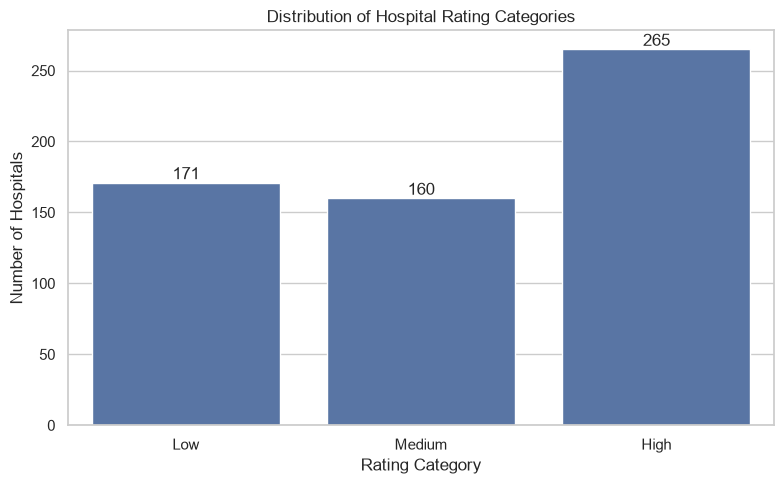

In [12]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=rated_df,
    x="rating_category",
    order=["Low", "Medium", "High"],
)

plt.title(
    "Distribution of Hospital Rating Categories"
)

plt.xlabel("Rating Category")
plt.ylabel("Number of Hospitals")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "rating_category_countplot.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

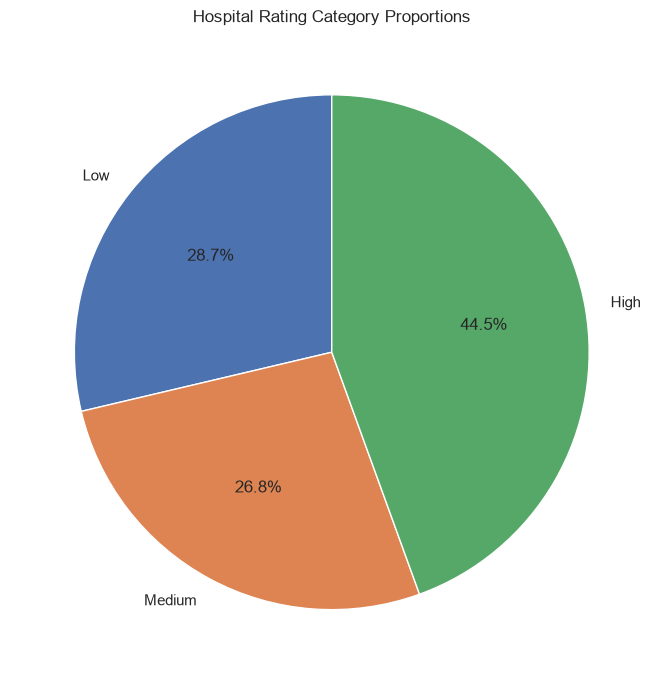

In [13]:
class_counts = (
    rated_df["rating_category"]
    .value_counts()
    .reindex(["Low", "Medium", "High"])
)

plt.figure(figsize=(7, 7))

plt.pie(
    class_counts.values,
    labels=class_counts.index,
    autopct="%1.1f%%",
    startangle=90,
)

plt.title(
    "Hospital Rating Category Proportions"
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "rating_category_piechart.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [14]:
print("=" * 70)
print("INITIAL EDA SUMMARY")
print("=" * 70)

print(f"Total observations : {len(df)}")
print(f"Total attributes   : {df.shape[1]}")

print(
    f"Rated hospitals    : "
    f"{len(rated_df)}"
)

print(
    f"Unrated hospitals  : "
    f"{df['rating_category'].isna().sum()}"
)

print("\nClass distribution:")

print(
    class_distribution.to_string(
        index=False
    )
)

INITIAL EDA SUMMARY
Total observations : 835
Total attributes   : 47
Rated hospitals    : 596
Unrated hospitals  : 239

Class distribution:
rating_category  count  percentage
            Low    171       28.69
         Medium    160       26.85
           High    265       44.46


In [15]:
distribution_features = [
    "overall_rating",
    "patient_survey_rating",
    "affiliated_clinicians",
    "total_better_measures",
    "total_worse_measures",
    "quality_balance_score",
    "better_measure_ratio",
    "worse_measure_ratio",
    "quality_coverage",
]

print(
    f"Numerical features selected for "
    f"distribution analysis: {len(distribution_features)}"
)

Numerical features selected for distribution analysis: 9


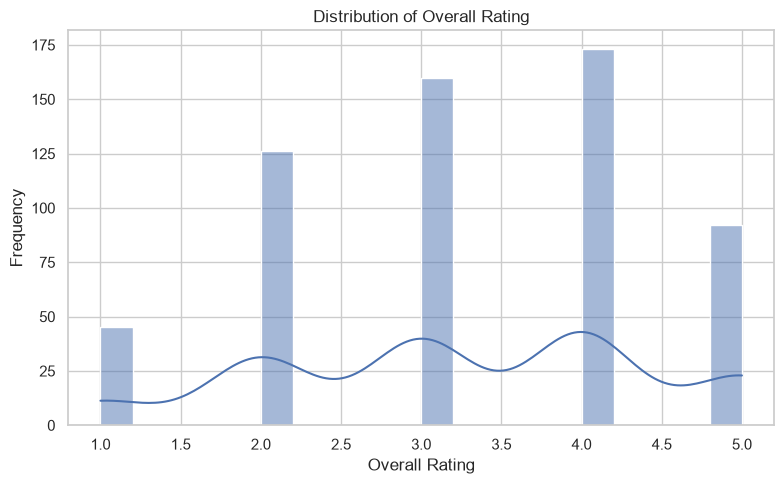

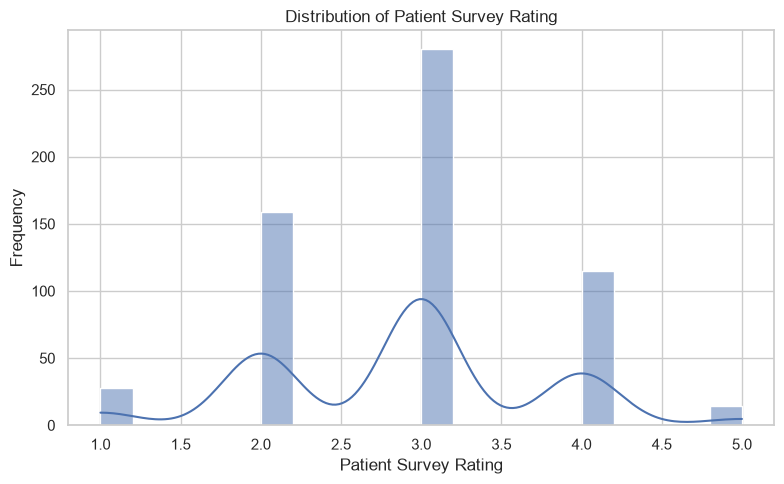

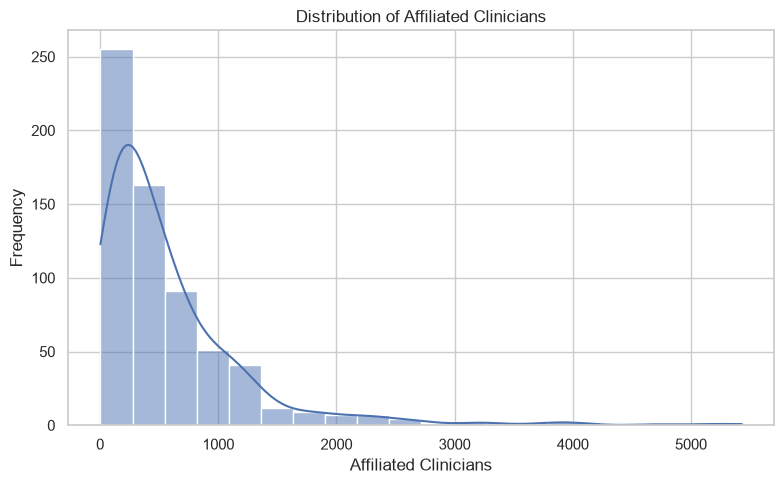

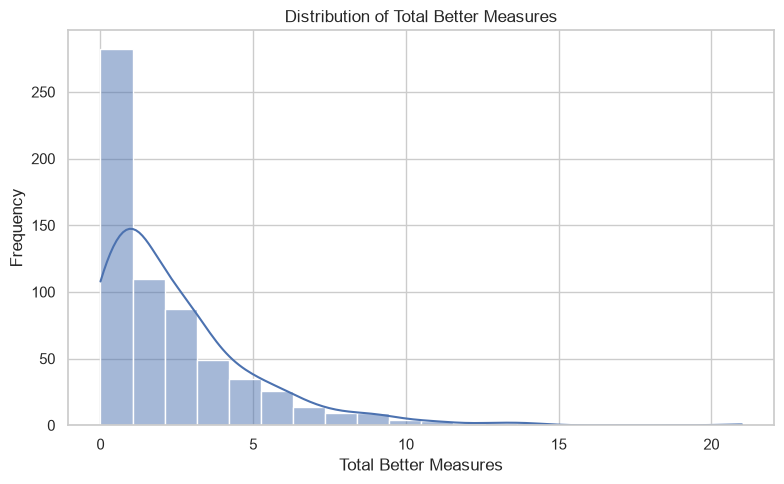

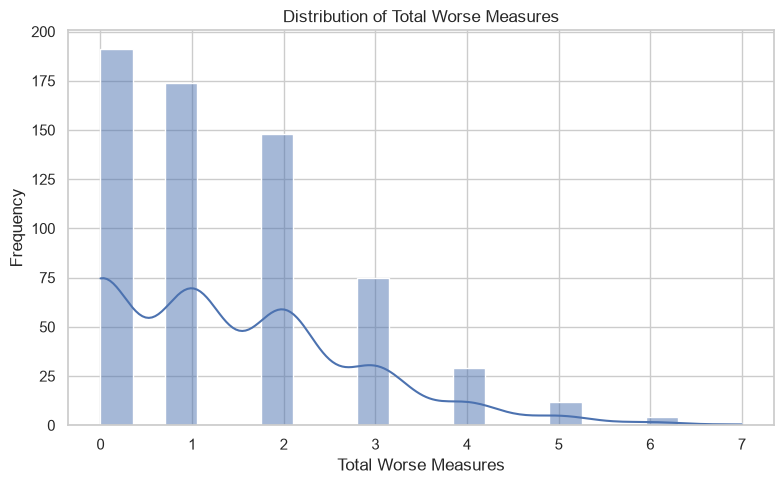

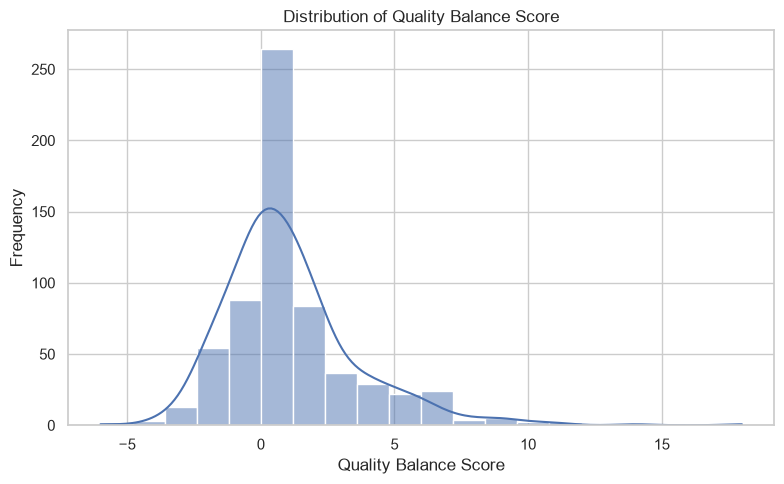

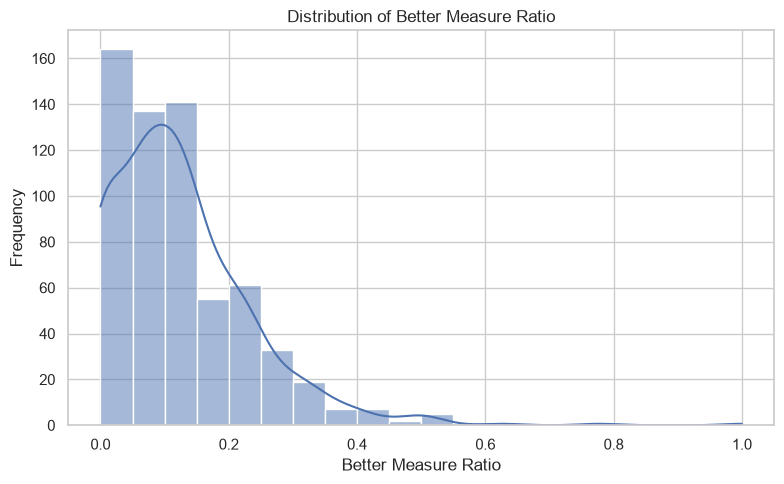

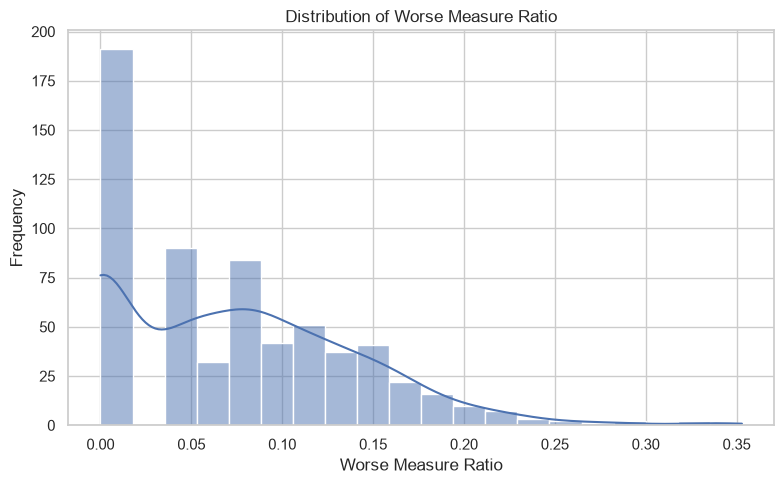

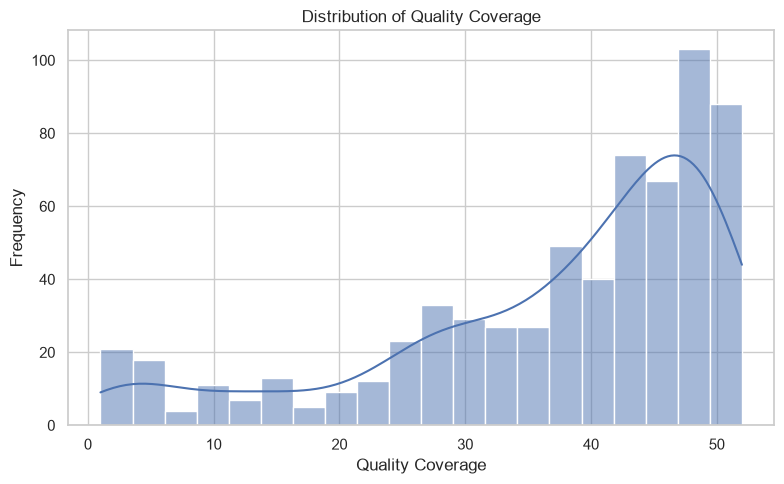

In [16]:
for feature in distribution_features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        bins=20,
        kde=True,
    )

    plt.title(
        f"Distribution of {feature.replace('_', ' ').title()}"
    )

    plt.xlabel(
        feature.replace("_", " ").title()
    )

    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.savefig(
        PLOT_DIR / f"{feature}_histogram.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

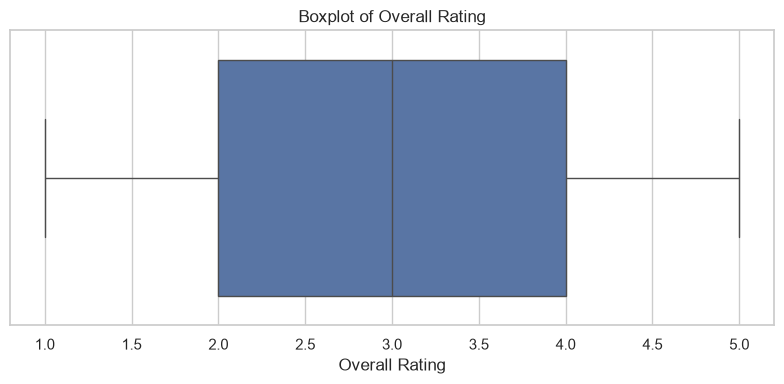

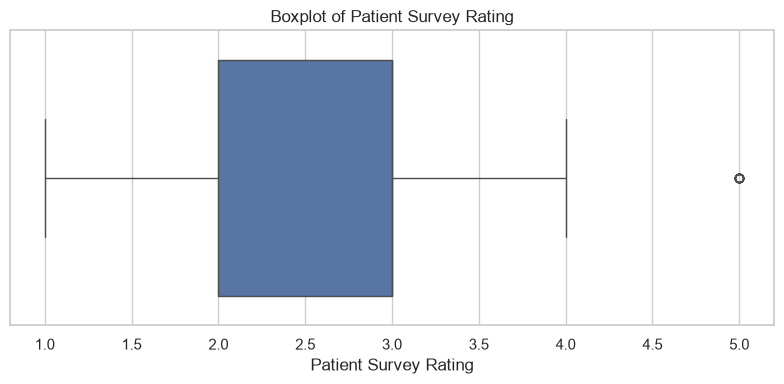

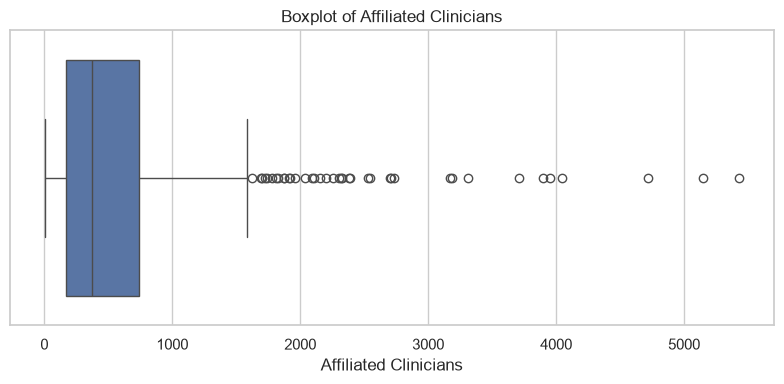

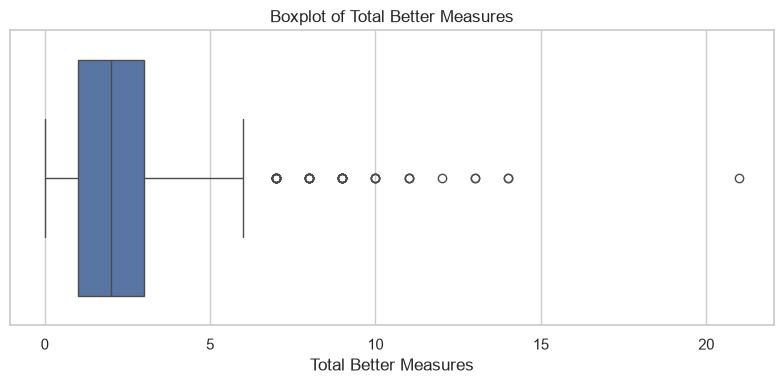

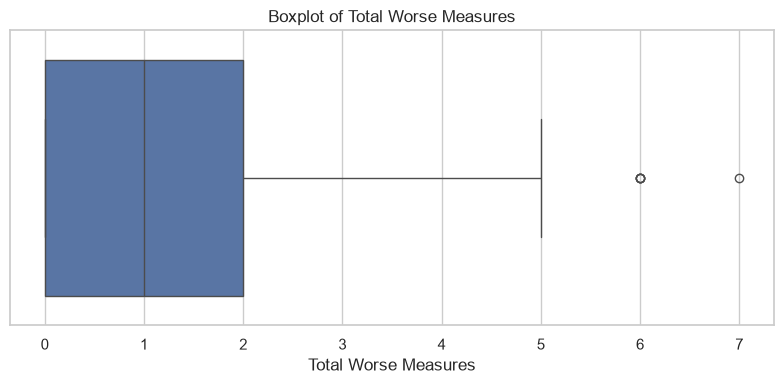

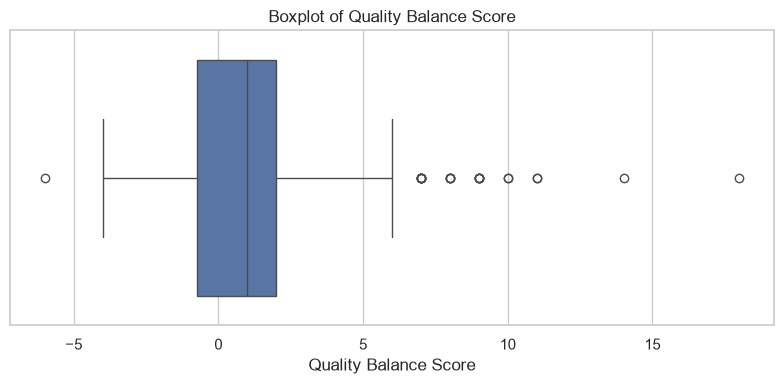

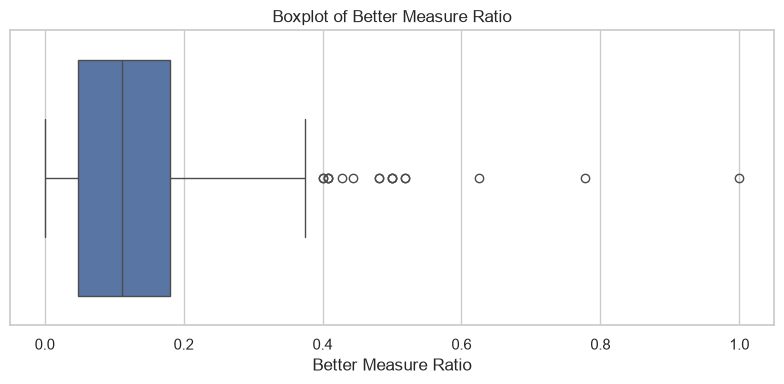

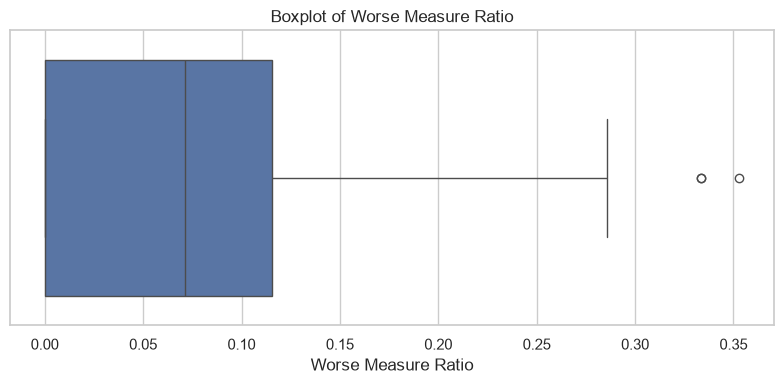

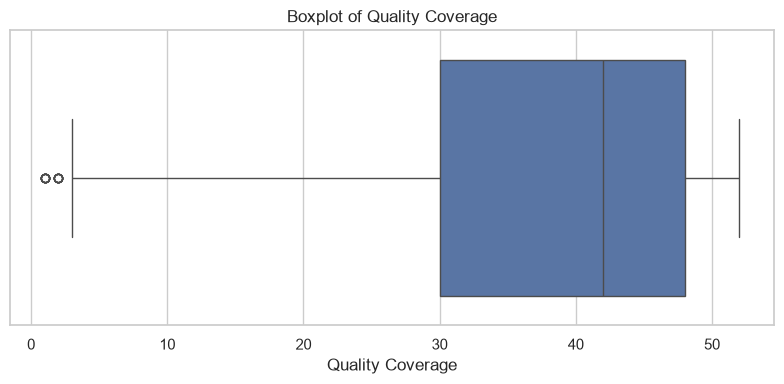

In [17]:
for feature in distribution_features:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=df,
        x=feature,
    )

    plt.title(
        f"Boxplot of {feature.replace('_', ' ').title()}"
    )

    plt.xlabel(
        feature.replace("_", " ").title()
    )

    plt.tight_layout()

    plt.savefig(
        PLOT_DIR / f"{feature}_boxplot.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

In [18]:
skewness_results = []

for feature in distribution_features:

    values = df[feature].dropna()

    skewness_results.append({
        "feature": feature,
        "skewness": values.skew(),
        "mean": values.mean(),
        "median": values.median(),
        "observations": len(values),
    })

skewness_df = pd.DataFrame(
    skewness_results
)

skewness_df["distribution_shape"] = (
    skewness_df["skewness"]
    .apply(
        lambda x:
            "Approximately Symmetric"
            if abs(x) < 0.5
            else (
                "Moderately Skewed"
                if abs(x) < 1
                else "Highly Skewed"
            )
    )
)

skewness_df.to_csv(
    REPORT_DIR / "skewness_analysis.csv",
    index=False,
)

skewness_df

,feature,skewness,mean,median,observations,distribution_shape
0,overall_rating,-0.171216,3.236577,3.000000,596,Approximately Symmetric
1,patient_survey_rating,0.005661,2.879195,3.000000,596,Approximately Symmetric
2,affiliated_clinicians,3.109688,579.907834,370.000000,651,Highly Skewed
3,total_better_measures,1.995027,2.493691,2.000000,634,Highly Skewed
4,total_worse_measures,0.923988,1.422713,1.000000,634,Moderately Skewed
5,quality_balance_score,1.500194,1.070978,1.000000,634,Highly Skewed
6,better_measure_ratio,1.915526,0.124603,0.111111,634,Highly Skewed
7,worse_measure_ratio,0.775048,0.073451,0.071429,634,Moderately Skewed
8,quality_coverage,-1.167902,37.050000,42.000000,660,Highly Skewed


In [19]:
outlier_results = []

for feature in distribution_features:

    values = df[feature].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = values[
        (values < lower_bound)
        | (values > upper_bound)
    ]

    outlier_results.append({
        "feature": feature,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers),
        "outlier_percentage": round(
            len(outliers) / len(values) * 100,
            2,
        ),
    })

outlier_df = pd.DataFrame(
    outlier_results
)

outlier_df.to_csv(
    REPORT_DIR / "eda_outlier_analysis.csv",
    index=False,
)

outlier_df

,feature,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,overall_rating,2.000000,4.000000,2.000000,-1.000000,7.000000,0,0.00
1,patient_survey_rating,2.000000,3.000000,1.000000,0.500000,4.500000,14,2.35
2,affiliated_clinicians,170.500000,739.000000,568.500000,-682.250000,1591.750000,39,5.99
3,total_better_measures,1.000000,3.000000,2.000000,-2.000000,6.000000,45,7.10
4,total_worse_measures,0.000000,2.000000,2.000000,-3.000000,5.000000,5,0.79
5,quality_balance_score,-0.750000,2.000000,2.750000,-4.875000,6.125000,23,3.63
6,better_measure_ratio,0.047619,0.180481,0.132862,-0.151674,0.379775,17,2.68
7,worse_measure_ratio,0.000000,0.115385,0.115385,-0.173077,0.288462,3,0.47
8,quality_coverage,30.000000,48.000000,18.000000,3.000000,75.000000,15,2.27


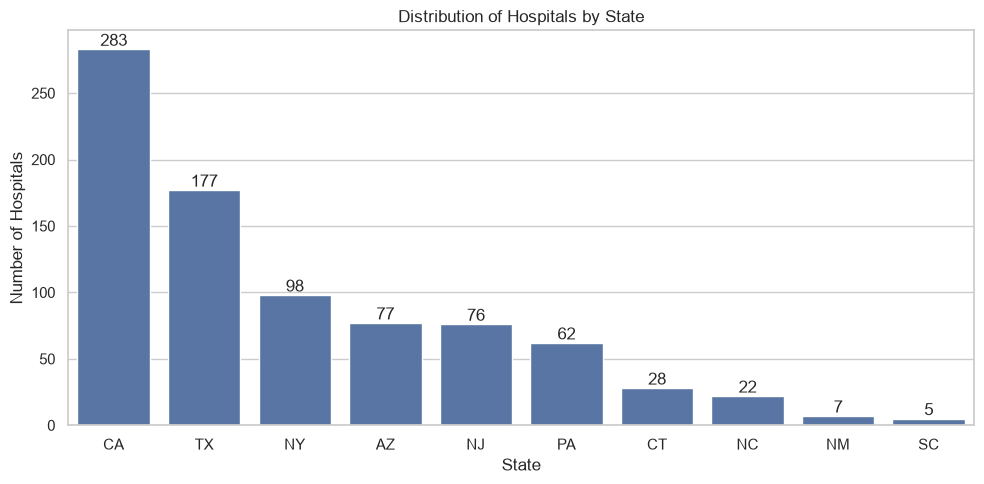

In [20]:
state_counts = (
    df["state"]
    .value_counts()
)

plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df,
    x="state",
    order=state_counts.index,
)

plt.title("Distribution of Hospitals by State")
plt.xlabel("State")
plt.ylabel("Number of Hospitals")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "state_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

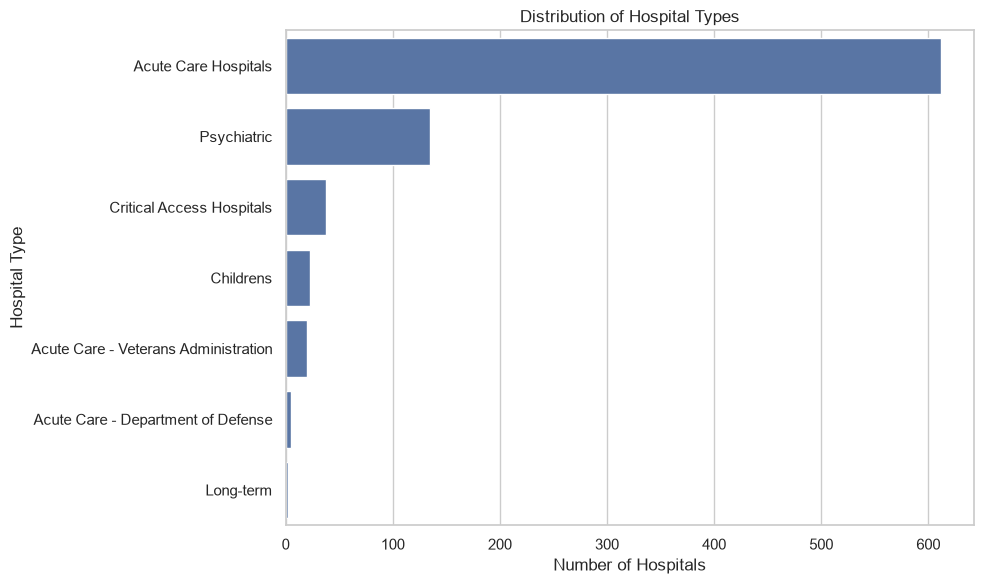

In [21]:
plt.figure(figsize=(10, 6))

order = (
    df["hospital_type"]
    .value_counts()
    .index
)

sns.countplot(
    data=df,
    y="hospital_type",
    order=order,
)

plt.title("Distribution of Hospital Types")
plt.xlabel("Number of Hospitals")
plt.ylabel("Hospital Type")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "hospital_type_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

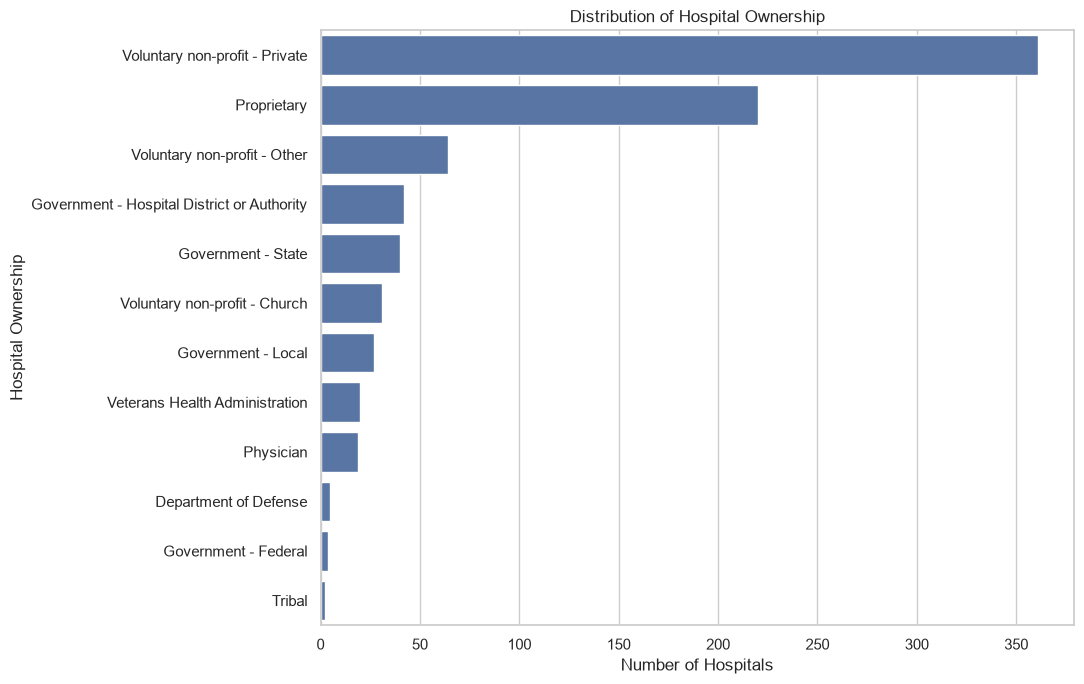

In [22]:
plt.figure(figsize=(11, 7))

order = (
    df["hospital_ownership"]
    .value_counts()
    .index
)

sns.countplot(
    data=df,
    y="hospital_ownership",
    order=order,
)

plt.title("Distribution of Hospital Ownership")
plt.xlabel("Number of Hospitals")
plt.ylabel("Hospital Ownership")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "hospital_ownership_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

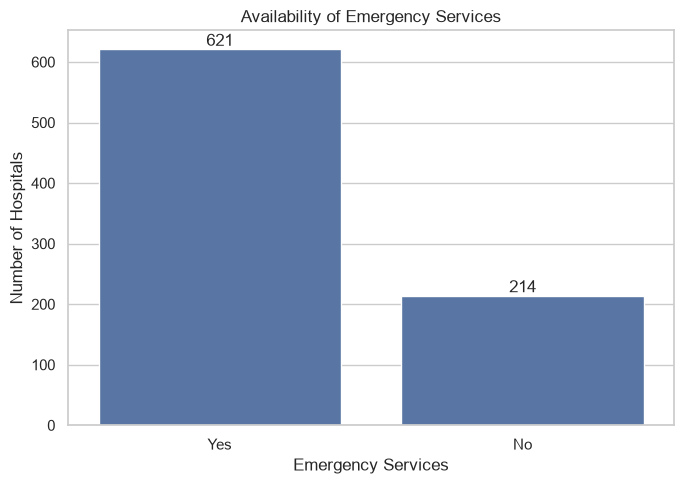

In [23]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="emergency_services",
)

plt.title("Availability of Emergency Services")
plt.xlabel("Emergency Services")
plt.ylabel("Number of Hospitals")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "emergency_services_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

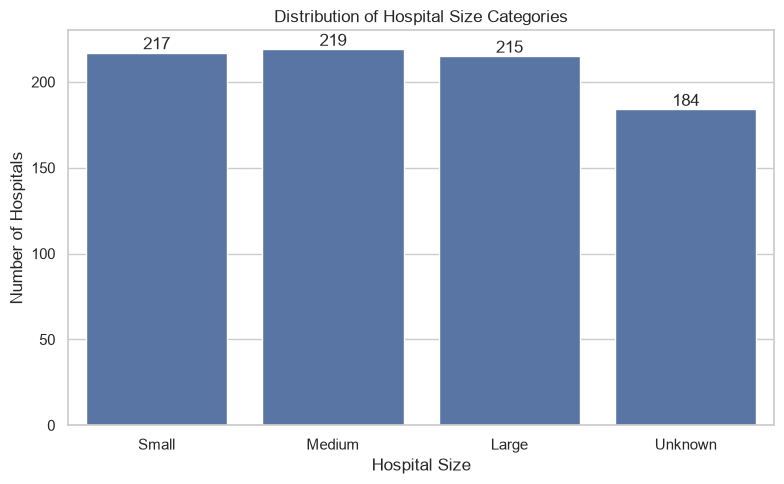

In [24]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="hospital_size_category",
    order=[
        "Small",
        "Medium",
        "Large",
        "Unknown",
    ],
)

plt.title("Distribution of Hospital Size Categories")
plt.xlabel("Hospital Size")
plt.ylabel("Number of Hospitals")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "hospital_size_distribution.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [25]:
correlation_features = [
    "overall_rating",
    "patient_survey_rating",
    "affiliated_clinicians",

    "mort_better",
    "mort_worse",
    "safety_better",
    "safety_worse",
    "readm_better",
    "readm_worse",

    "total_better_measures",
    "total_worse_measures",
    "quality_balance_score",
    "better_measure_ratio",
    "worse_measure_ratio",
    "quality_coverage",
]

correlation_data = df[
    correlation_features
].copy()

print(
    f"Correlation analysis using "
    f"{len(correlation_features)} numerical features."
)

Correlation analysis using 15 numerical features.


In [26]:
correlation_matrix = (
    correlation_data
    .corr(method="pearson")
)

correlation_matrix.to_csv(
    REPORT_DIR / "correlation_matrix.csv"
)

correlation_matrix.round(3)

,overall_rating,patient_survey_rating,affiliated_clinicians,mort_better,mort_worse,safety_better,safety_worse,readm_better,readm_worse,total_better_measures,total_worse_measures,quality_balance_score,better_measure_ratio,worse_measure_ratio,quality_coverage
overall_rating,1.000,0.615,0.371,0.404,-0.199,0.176,-0.107,0.388,-0.243,0.412,-0.291,0.545,0.411,-0.363,0.081
patient_survey_rating,0.615,1.000,0.199,0.129,-0.085,-0.043,-0.004,0.210,-0.218,0.107,-0.213,0.211,0.122,-0.221,-0.066
affiliated_clinicians,0.371,0.199,1.000,0.673,0.028,0.570,0.199,0.477,0.327,0.765,0.336,0.589,0.553,0.120,0.525
mort_better,0.404,0.129,0.673,1.000,-0.077,0.388,0.117,0.397,0.240,0.813,0.212,0.692,0.700,0.064,0.337
mort_worse,-0.199,-0.085,0.028,-0.077,1.000,0.074,0.094,0.024,0.137,0.011,0.428,-0.208,-0.032,0.328,0.162
safety_better,0.176,-0.043,0.570,0.388,0.074,1.000,0.149,0.280,0.305,0.775,0.318,0.598,0.647,0.097,0.563
safety_worse,-0.107,-0.004,0.199,0.117,0.094,0.149,1.000,0.016,0.125,0.137,0.380,-0.059,0.076,0.338,0.144
readm_better,0.388,0.210,0.477,0.397,0.024,0.280,0.016,1.000,-0.131,0.666,-0.099,0.712,0.666,-0.208,0.283
readm_worse,-0.243,-0.218,0.327,0.240,0.137,0.305,0.125,-0.131,1.000,0.241,0.924,-0.237,0.093,0.808,0.463
total_better_measures,0.412,0.107,0.765,0.813,0.011,0.775,0.137,0.666,0.241,1.000,0.247,0.865,0.838,0.028,0.546


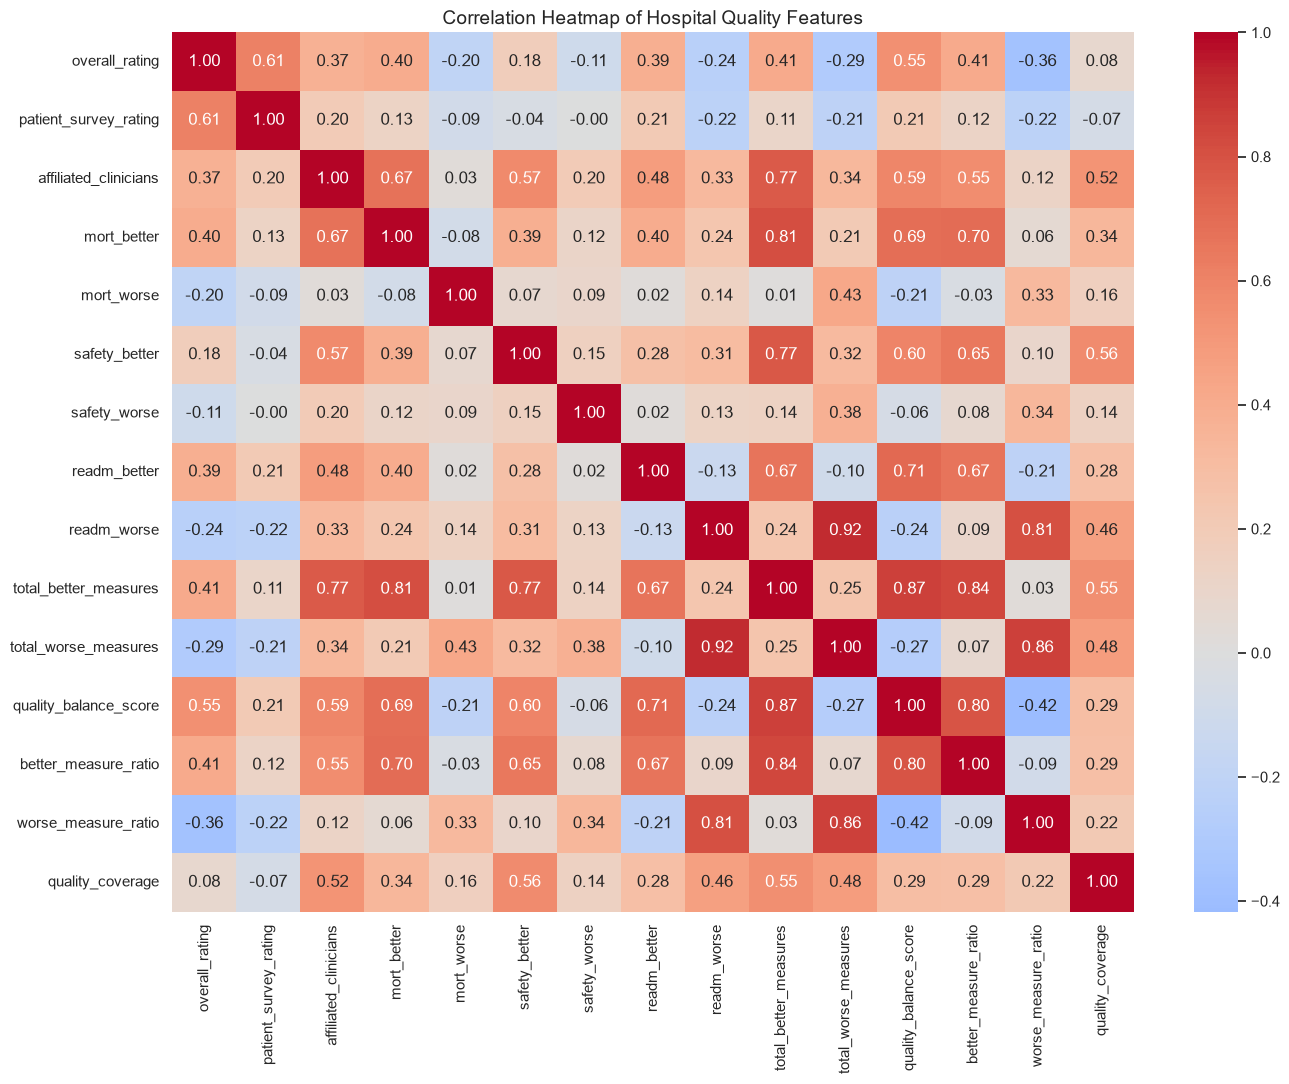

In [27]:
plt.figure(
    figsize=(14, 11)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False,
)

plt.title(
    "Correlation Heatmap of Hospital Quality Features",
    fontsize=14,
)

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [28]:
rating_correlations = (
    correlation_matrix["overall_rating"]
    .drop("overall_rating")
    .sort_values(
        key=abs,
        ascending=False,
    )
    .reset_index()
)

rating_correlations.columns = [
    "feature",
    "correlation_with_overall_rating",
]

rating_correlations.to_csv(
    REPORT_DIR / "overall_rating_correlations.csv",
    index=False,
)

rating_correlations

,feature,correlation_with_overall_rating
0,patient_survey_rating,0.614781
1,quality_balance_score,0.545146
2,total_better_measures,0.411833
3,better_measure_ratio,0.410554
4,mort_better,0.403663
5,readm_better,0.387647
6,affiliated_clinicians,0.371425
7,worse_measure_ratio,-0.362938
8,total_worse_measures,-0.291034
9,readm_worse,-0.242586


In [29]:
correlation_pairs = []

columns = correlation_matrix.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):

        feature_1 = columns[i]
        feature_2 = columns[j]

        correlation = (
            correlation_matrix.loc[
                feature_1,
                feature_2,
            ]
        )

        correlation_pairs.append({
            "feature_1": feature_1,
            "feature_2": feature_2,
            "correlation": correlation,
            "absolute_correlation": abs(correlation),
        })


strongest_correlations = (
    pd.DataFrame(correlation_pairs)
    .sort_values(
        "absolute_correlation",
        ascending=False,
    )
    .reset_index(drop=True)
)

strongest_correlations.to_csv(
    REPORT_DIR / "strongest_correlations.csv",
    index=False,
)

strongest_correlations.head(15)

,feature_1,feature_2,correlation,absolute_correlation
0,readm_worse,total_worse_measures,0.923688,0.923688
1,total_better_measures,quality_balance_score,0.865235,0.865235
2,total_worse_measures,worse_measure_ratio,0.861192,0.861192
3,total_better_measures,better_measure_ratio,0.837707,0.837707
4,mort_better,total_better_measures,0.812935,0.812935
5,readm_worse,worse_measure_ratio,0.807902,0.807902
6,quality_balance_score,better_measure_ratio,0.795090,0.795090
7,safety_better,total_better_measures,0.774865,0.774865
8,affiliated_clinicians,total_better_measures,0.765151,0.765151
9,readm_better,quality_balance_score,0.711644,0.711644


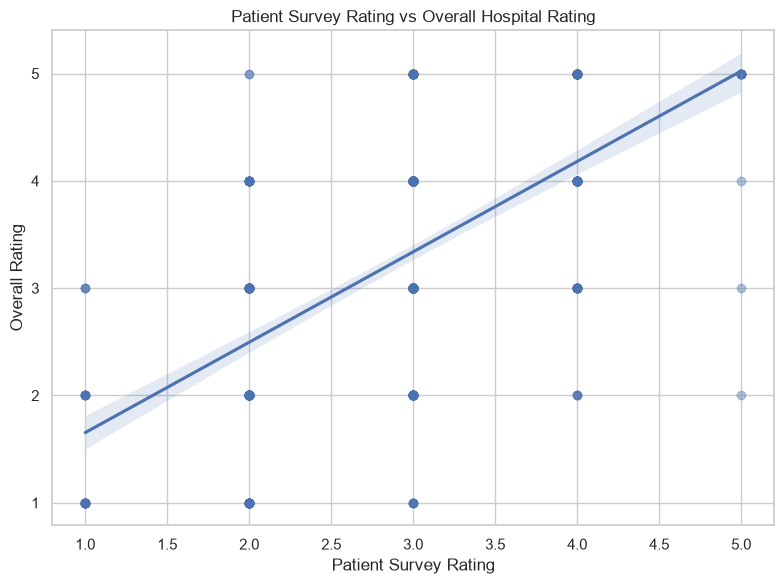

In [30]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="patient_survey_rating",
    y="overall_rating",
    scatter_kws={
        "alpha": 0.4
    },
)

plt.title(
    "Patient Survey Rating vs Overall Hospital Rating"
)

plt.xlabel("Patient Survey Rating")
plt.ylabel("Overall Rating")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "patient_survey_vs_overall_rating.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

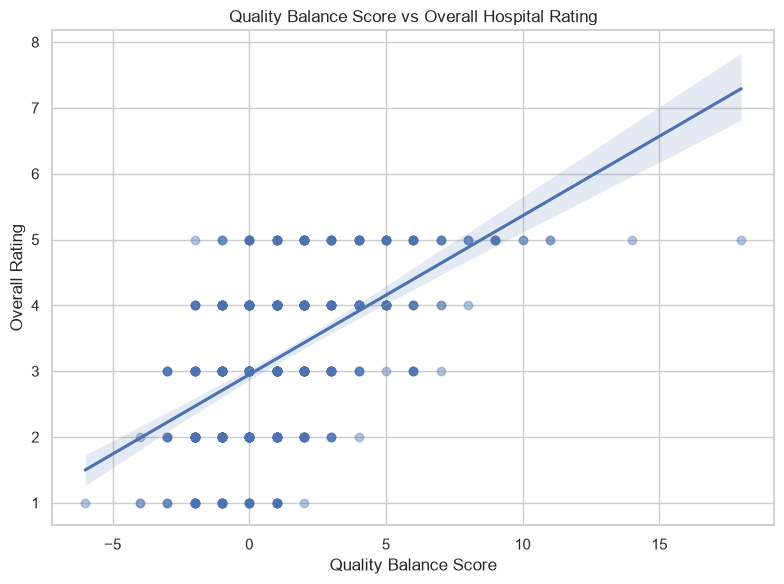

In [31]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="quality_balance_score",
    y="overall_rating",
    scatter_kws={
        "alpha": 0.4
    },
)

plt.title(
    "Quality Balance Score vs Overall Hospital Rating"
)

plt.xlabel("Quality Balance Score")
plt.ylabel("Overall Rating")

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "quality_balance_vs_overall_rating.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [32]:
from scipy import stats

In [33]:
clinician_data = (
    df["affiliated_clinicians"]
    .dropna()
    .values
)

candidate_distributions = {
    "Normal": stats.norm,
    "Lognormal": stats.lognorm,
    "Gamma": stats.gamma,
    "Exponential": stats.expon,
}

distribution_results = []

for name, distribution in candidate_distributions.items():

    params = distribution.fit(clinician_data)

    ks_statistic, p_value = stats.kstest(
        clinician_data,
        distribution.cdf,
        args=params,
    )

    distribution_results.append({
        "distribution": name,
        "ks_statistic": ks_statistic,
        "p_value": p_value,
    })


distribution_fit_df = (
    pd.DataFrame(distribution_results)
    .sort_values("ks_statistic")
    .reset_index(drop=True)
)

distribution_fit_df.to_csv(
    REPORT_DIR / "distribution_fit_results.csv",
    index=False,
)

distribution_fit_df

,distribution,ks_statistic,p_value
0,Lognormal,0.035256,3.844648e-01
1,Exponential,0.037968,2.975037e-01
2,Gamma,0.086367,1.128644e-04
3,Normal,0.193328,8.679198e-22


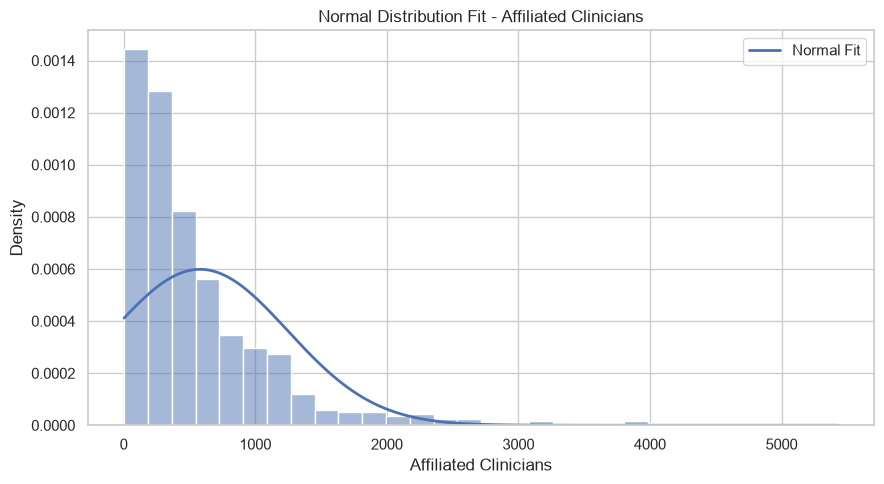

In [34]:
x = np.linspace(
    clinician_data.min(),
    clinician_data.max(),
    500,
)

normal_params = stats.norm.fit(
    clinician_data
)

plt.figure(figsize=(9, 5))

sns.histplot(
    clinician_data,
    bins=30,
    stat="density",
    alpha=0.5,
)

plt.plot(
    x,
    stats.norm.pdf(
        x,
        *normal_params
    ),
    linewidth=2,
    label="Normal Fit",
)

plt.title(
    "Normal Distribution Fit - Affiliated Clinicians"
)

plt.xlabel("Affiliated Clinicians")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "affiliated_clinicians_normal_fit.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

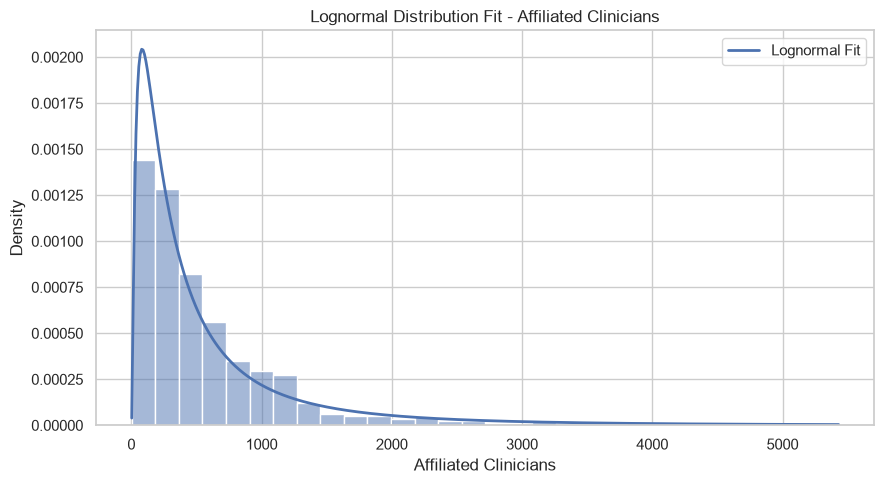

In [35]:
lognormal_params = stats.lognorm.fit(
    clinician_data,
    floc=0,
)

plt.figure(figsize=(9, 5))

sns.histplot(
    clinician_data,
    bins=30,
    stat="density",
    alpha=0.5,
)

plt.plot(
    x,
    stats.lognorm.pdf(
        x,
        *lognormal_params
    ),
    linewidth=2,
    label="Lognormal Fit",
)

plt.title(
    "Lognormal Distribution Fit - Affiliated Clinicians"
)

plt.xlabel("Affiliated Clinicians")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

plt.savefig(
    PLOT_DIR / "affiliated_clinicians_lognormal_fit.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [36]:
emergency_yes = (
    df.loc[
        df["emergency_services"] == "Yes",
        "overall_rating",
    ]
    .dropna()
)

emergency_no = (
    df.loc[
        df["emergency_services"] == "No",
        "overall_rating",
    ]
    .dropna()
)

t_statistic, t_pvalue = stats.ttest_ind(
    emergency_yes,
    emergency_no,
    equal_var=False,
)

print("INDEPENDENT T-TEST")
print("=" * 50)

print(
    f"Emergency services - Yes: "
    f"n={len(emergency_yes)}, "
    f"mean={emergency_yes.mean():.3f}"
)

print(
    f"Emergency services - No : "
    f"n={len(emergency_no)}, "
    f"mean={emergency_no.mean():.3f}"
)

print(f"\nT-statistic : {t_statistic:.4f}")
print(f"P-value     : {t_pvalue:.6f}")

INDEPENDENT T-TEST
Emergency services - Yes: n=535, mean=3.232
Emergency services - No : n=61, mean=3.279

T-statistic : -0.3031
P-value     : 0.762655


In [37]:
chi_df = df[
    df["rating_category"].notna()
    & df["hospital_size_category"].isin(
        ["Small", "Medium", "Large"]
    )
].copy()

contingency_table = pd.crosstab(
    chi_df["hospital_size_category"],
    chi_df["rating_category"],
)

chi2_statistic, chi2_pvalue, dof, expected = (
    stats.chi2_contingency(
        contingency_table
    )
)

print("CHI-SQUARE TEST OF INDEPENDENCE")
print("=" * 50)

display(contingency_table)

print(f"\nChi-square statistic : {chi2_statistic:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"P-value              : {chi2_pvalue:.6f}")

CHI-SQUARE TEST OF INDEPENDENCE


rating_category,High,Low,Medium
hospital_size_category,,,
Large,130,26,58
Medium,76,85,54
Small,39,57,42



Chi-square statistic : 61.8566
Degrees of freedom   : 4
P-value              : 0.000000


In [38]:
low_survey = (
    rated_df.loc[
        rated_df["rating_category"] == "Low",
        "patient_survey_rating",
    ]
    .dropna()
)

medium_survey = (
    rated_df.loc[
        rated_df["rating_category"] == "Medium",
        "patient_survey_rating",
    ]
    .dropna()
)

high_survey = (
    rated_df.loc[
        rated_df["rating_category"] == "High",
        "patient_survey_rating",
    ]
    .dropna()
)

f_statistic, anova_pvalue = stats.f_oneway(
    low_survey,
    medium_survey,
    high_survey,
)

print("ONE-WAY ANOVA")
print("=" * 50)

print(
    f"Low    : n={len(low_survey)}, "
    f"mean={low_survey.mean():.3f}"
)

print(
    f"Medium : n={len(medium_survey)}, "
    f"mean={medium_survey.mean():.3f}"
)

print(
    f"High   : n={len(high_survey)}, "
    f"mean={high_survey.mean():.3f}"
)

print(f"\nF-statistic : {f_statistic:.4f}")
print(f"P-value     : {anova_pvalue:.8f}")

ONE-WAY ANOVA
Low    : n=171, mean=2.222
Medium : n=160, mean=2.769
High   : n=265, mean=3.370

F-statistic : 140.8469
P-value     : 0.00000000


In [39]:
alpha = 0.05

hypothesis_results = pd.DataFrame([
    {
        "test": "Welch Independent T-Test",
        "research_question":
            "Does mean overall rating differ by "
            "emergency service availability?",
        "statistic": t_statistic,
        "p_value": t_pvalue,
        "alpha": alpha,
        "decision":
            "Reject H0"
            if t_pvalue < alpha
            else "Fail to Reject H0",
    },

    {
        "test": "Chi-Square Test",
        "research_question":
            "Is hospital size associated with "
            "rating category?",
        "statistic": chi2_statistic,
        "p_value": chi2_pvalue,
        "alpha": alpha,
        "decision":
            "Reject H0"
            if chi2_pvalue < alpha
            else "Fail to Reject H0",
    },

    {
        "test": "One-Way ANOVA",
        "research_question":
            "Does patient survey rating differ "
            "across rating categories?",
        "statistic": f_statistic,
        "p_value": anova_pvalue,
        "alpha": alpha,
        "decision":
            "Reject H0"
            if anova_pvalue < alpha
            else "Fail to Reject H0",
    },
])

hypothesis_results.to_csv(
    REPORT_DIR / "hypothesis_test_results.csv",
    index=False,
)

hypothesis_results

,test,research_question,statistic,p_value,alpha,decision
0,Welch Independent T-Test,Does mean overall rating differ by emergency s...,-0.303094,7.626552e-01,0.05,Fail to Reject H0
1,Chi-Square Test,Is hospital size associated with rating category?,61.856621,1.180814e-12,0.05,Reject H0
2,One-Way ANOVA,Does patient survey rating differ across ratin...,140.846851,8.920986e-51,0.05,Reject H0
